**Penerapan Exploratory Data Analysis untuk Analisis Jenis Customer Kelompok Industri dengan Software Tableau**

**Topik Permasalahan**:
Perusahaan menginginkan untuk mengetahui visualisasi data yang hanya menampilkan perusahaan pelanggan yang termasuk ke dalam kelompok industri, yang dimana diketahui berupa (RT 1 itu Rumah Tangga 1, dia pelanggan harga Rp4.750 paling murah karena dari segi ekonomi menengah ke bawah), (RT 2 itu Rumah Rangga 2, dia pelanggan harga Rp6.200 untuk pelanggan ekonomi menengah), (GPiR itu Gas Pintar Rumah, dia pelanggan harga Rp10.000 untuk pelanggan ekonomi menengah keatas), (PK2 itu pelanggan kecil 2, harga Rp6.200 untuk pelanggan komrsial program dari pemerintah), (GPiK itu Gas Kita Praktis, harga Rp10.000, untuk pelanggan komersial program dari PGN), (Bronze 1, Bronze 2, Bronze 3, IMP3 dan Silver itu industri).

**Solusi**:
Exploratory Data Analysis (EDA) dilakukan menggunakan Google Colab dengan library Pandas untuk membaca, memeriksa, dan melakukan penyaringan data berdasarkan jenis customer. Data kemudian difokuskan pada kelompok industri, yaitu Bronze 1, Bronze 2, Bronze 3, IMP3, dan Silver.

Setelah proses pengolahan dan penyaringan data di Google Colab selesai, data digunakan pada software Tableau untuk membuat visualisasi. Visualisasi digunakan untuk melihat pola pemakaian gas pelanggan industri sepanjang periode 2021–2023 berdasarkan Terhitung m3 dan periode. Hasil visualisasi diharapkan dapat membantu perusahaan mengetahui kelompok pelanggan industri yang memiliki biaya pemakaian paling tinggi maupun perubahan biaya pemakaian dari waktu ke waktu.


#Persiapan Data
Memuat data asli

In [1]:
import pandas as pd
data = pd.read_excel("/content/data_fix.xlsx")
data

,No Ref,Account Name,Buku,Periode,Jenis Customer,Batas Min,Batas Max,Terukur m3,Terhitung m3,Terukur mmbtu,Terhitung mmbtu,Biaya Pemakaian Rp,Harga (Rp),Terhitung Normal m3,Terhitung Normal mmbtu,Tagihan Normal Rp,Kode Harga
0,18561358.0,"GAGAS ENERGI INDONESIA, PT. (SPBG LAMPUNG)",1.0,2021-01-01,IJK3,692500.0,831000.0,134471.18,134471.18,4688.8811,4688.8811,60512031.0,450.0,134471.1800,4688.8811,60512031.0,GAGAS_HYBRID
1,18561358.0,"GAGAS ENERGI INDONESIA, PT. (SPBG LAMPUNG)",1.0,2021-01-01,IJK3,NaN,NaN,2499.16,2499.16,87.1433,87.1433,0.0,0.0,2499.1600,87.1433,0.0,GAGAS_HYBRID
2,18561358.0,"GAGAS ENERGI INDONESIA, PT. (SPBG LAMPUNG)",1.0,2021-01-01,IJK3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,GAGAS_HYBRID
3,18527068.0,"SUMBER INDAHPERKASA, PT.",1.0,2021-01-01,Bronze 3,15000.0,18000.0,554307.74,554307.74,20196.4335,20196.4335,0.0,0.0,493834.7727,18000.0000,0.0,PBr3B
4,18661807.0,KHAIRUDIN M PENGKY,14.0,2021-01-01,RT1,4.0,50.0,9.00,9.00,0.3297,0.3297,42750.0,4750.0,9.0000,0.3297,42750.0,RT1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578616,275927.0,UJANG SAAD,37.0,2023-12-01,GPiR,4.0,50.0,28.00,28.00,1.0208,1.0208,280000.0,10000.0,28.0000,1.0208,280000.0,PGPiR
578617,271804.0,WIRA WIJAYA,37.0,2023-12-01,GPiR,4.0,50.0,7.00,7.00,0.2552,0.2552,70000.0,10000.0,7.0000,0.2552,70000.0,PGPiR
578618,286313.0,YEYEN SUVENDA,37.0,2023-12-01,GPiR,4.0,50.0,1.00,4.00,0.0365,0.1458,40000.0,10000.0,1.0000,0.0365,10000.0,PGPiR
578619,239700.0,HERAWATI AMD,38.0,2023-12-01,GPiR,4.0,50.0,8.00,8.00,0.2916,0.2916,80000.0,10000.0,8.0000,0.2916,80000.0,PGPiR


Bagaimana bentuk data/jenis data/tipe data pada kolom yang ada?

In [2]:
# Mengetahui ukuran data
data.shape

(578621, 17)

In [3]:
# Melihat nama kolom
data.columns

Index(['No Ref', 'Account Name', 'Buku', 'Periode', 'Jenis Customer',
       'Batas Min', 'Batas Max', 'Terukur m3', 'Terhitung m3', 'Terukur mmbtu',
       'Terhitung mmbtu', 'Biaya Pemakaian Rp', 'Harga (Rp)',
       'Terhitung Normal m3', 'Terhitung Normal mmbtu', 'Tagihan Normal Rp',
       'Kode Harga'],
      dtype='object')

In [4]:
# Melihat informasi data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578621 entries, 0 to 578620
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   No Ref                  578615 non-null  float64       
 1   Account Name            566251 non-null  object        
 2   Buku                    578619 non-null  float64       
 3   Periode                 578619 non-null  datetime64[ns]
 4   Jenis Customer          578619 non-null  object        
 5   Batas Min               578595 non-null  float64       
 6   Batas Max               578596 non-null  float64       
 7   Terukur m3              578608 non-null  float64       
 8   Terhitung m3            578596 non-null  float64       
 9   Terukur mmbtu           578607 non-null  float64       
 10  Terhitung mmbtu         578597 non-null  float64       
 11  Biaya Pemakaian Rp      578501 non-null  float64       
 12  Harga (Rp)              578492

In [5]:
# Mengecek persentase missing value
missing = data.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase Missing (%)': (missing / len(data) * 100).round(2)
})

missing_df.sort_values(
    by='Jumlah Missing',
    ascending=False
)

,Jumlah Missing,Persentase Missing (%)
Account Name,12370,2.14
Tagihan Normal Rp,134,0.02
Harga (Rp),129,0.02
Biaya Pemakaian Rp,120,0.02
Batas Min,26,0.00
Terhitung m3,25,0.00
Batas Max,25,0.00
Terhitung mmbtu,24,0.00
Terukur mmbtu,14,0.00
Terhitung Normal mmbtu,13,0.00


In [6]:
# Investigasi Account Name yang kosong
data[data['Account Name'].isnull()].head(20)

,No Ref,Account Name,Buku,Periode,Jenis Customer,Batas Min,Batas Max,Terukur m3,Terhitung m3,Terukur mmbtu,Terhitung mmbtu,Biaya Pemakaian Rp,Harga (Rp),Terhitung Normal m3,Terhitung Normal mmbtu,Tagihan Normal Rp,Kode Harga
19226,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19227,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40984,213.0,NaN,29.0,2021-05-01,RT1,4.0,50.0,15.0,15.0,0.5495,0.5495,71250.0,4750.0,15.0,0.5495,71250.0,RT1
40985,267.0,NaN,29.0,2021-05-01,RT1,4.0,50.0,20.0,20.0,0.7326,0.7326,95000.0,4750.0,20.0,0.7326,95000.0,RT1
40986,324.0,NaN,29.0,2021-05-01,RT1,4.0,50.0,11.0,11.0,0.4030,0.4030,52250.0,4750.0,11.0,0.4030,52250.0,RT1
40987,366.0,NaN,31.0,2021-05-01,RT2,4.0,50.0,11.0,11.0,0.4030,0.4030,68200.0,6200.0,11.0,0.4030,68200.0,RT2
40988,387.0,NaN,31.0,2021-05-01,RT1,4.0,50.0,2.0,4.0,0.0733,0.1465,19000.0,4750.0,2.0,0.0733,9500.0,RT1
40989,392.0,NaN,29.0,2021-05-01,RT1,4.0,50.0,13.0,13.0,0.4762,0.4762,61750.0,4750.0,13.0,0.4762,61750.0,RT1
40990,420.0,NaN,31.0,2021-05-01,RT2,4.0,50.0,0.0,4.0,0.0000,0.1465,24800.0,6200.0,0.0,0.0000,0.0,RT2
40991,421.0,NaN,31.0,2021-05-01,RT1,4.0,50.0,7.0,7.0,0.2564,0.2564,33250.0,4750.0,7.0,0.2564,33250.0,RT1


In [7]:
# Hapus Baris yang Benar-benar Kosong
data_clean = data.dropna(how='all').copy()

In [8]:
print("Jumlah data sebelum cleaning:", len(data))
print("Jumlah data setelah cleaning:", len(data_clean))
print("Jumlah baris yang dihapus:", len(data) - len(data_clean))

Jumlah data sebelum cleaning: 578621
Jumlah data setelah cleaning: 578619
Jumlah baris yang dihapus: 2


In [9]:
# Dari 12.368 baris yang Account Name-nya masih kosong, apakah ada yang termasuk customer industri?
data_clean[data_clean['Account Name'].isnull()]['Jenis Customer'].value_counts(dropna=False)

,count
Jenis Customer,
RT1,9784
RT2,2510
PK2,26
Bronze 3,15
IJK3,13
Bronze 1,10
Bronze 2,5
Silver,3
IMP3,2


Bronze 1 ada 10, Bronze 2 ada 5, Bronze 3 ada 15, Silver ada 3, IMP3 ada 2. Artinya ada 35 baris customer industri yang Account Name-nya kosong.

In [10]:
# Cek duplikasi
data_clean.duplicated().sum()

np.int64(0)

In [11]:
# Cek jenis customer
data_clean['Jenis Customer'].value_counts(dropna=False)

,count
Jenis Customer,
RT1,452998
RT2,103048
GPiR,20169
PK2,1000
Bronze 1,538
GPiK,214
Bronze 3,208
Bronze 2,188
IMP3,109


Memfilter customer yang termasuk ke dalam customer Industri

In [12]:
# Filter customer Industri
customer_industri = [
    'Bronze 1',
    'Bronze 2',
    'Bronze 3',
    'IMP3',
    'Silver'
]

data_industri = data_clean[
    data_clean['Jenis Customer'].isin(customer_industri)
].copy()

data_industri.shape

(1106, 17)

Terdapat 1106 data yang termasuk ke dalam customer industri, pengecekan rentag data untuk mengetahui apakah tahun yang diminta oleh perusahaan 2021-2023 ada atau tidak?

In [13]:
# Cek rentang periode
print("Periode paling awal:", data_industri['Periode'].min())
print("Periode paling akhir:", data_industri['Periode'].max())

print("\nJumlah transaksi per tahun:")
print(data_industri['Periode'].dt.year.value_counts().sort_index())

Periode paling awal: 2021-01-01 00:00:00
Periode paling akhir: 2023-12-01 00:00:00

Jumlah transaksi per tahun:
Periode
2021    332
2022    341
2023    433
Name: count, dtype: int64


Pembuatan kolom Tahun agar dapat di visualisasikan nanti sesuai tahun yang di minta perusahaan

In [14]:
# Membuat kolom Tahun
data_industri['Tahun'] = data_industri['Periode'].dt.year

data_industri[['Periode', 'Tahun']].head()

,Periode,Tahun
3,2021-01-01,2021
224,2021-01-01,2021
1080,2021-01-01,2021
4610,2021-01-01,2021
5295,2021-01-01,2021


#Exploratory Data Analysis (EDA)

Dengan menggunakan kolom Terhitung m3 sesusai arahan mentor untuk menghitung total pemakaian gas yang digunakan oleh pelanggan gas di Kota Bandar Lampung. Sebab kolom Terukur m3 mewakili penggunaan terukur dan kolom Terhitung mmbtu mewakili penggunaan energi

In [16]:
# Cek ada data kosong pada penggunaan gas
data_industri['Terhitung m3'].isnull().sum()

np.int64(0)

In [17]:
# Cek statistik
data_industri['Terhitung m3'].describe()

,Terhitung m3
count,1.106000e+03
mean,4.657366e+05
std,1.945959e+06
min,0.000000e+00
25%,1.538759e+03
50%,9.946185e+03
75%,8.076707e+04
max,1.429815e+07


In [18]:
# Cek penggunaan gas berdasarkan jenis customer
# Jenis customer industri mana yang memiliki penggunaan gas paling tinggi?
data_industri.groupby('Jenis Customer')['Terhitung m3'].agg(
    Rata_Rata='mean',
    Median='median',
    Total='sum',
    Minimum='min',
    Maksimum='max',
    Jumlah_Transaksi='count'
).sort_values('Rata_Rata', ascending=False)

,Rata_Rata,Median,Total,Minimum,Maksimum,Jumlah_Transaksi
Jenis Customer,,,,,,
IMP3,4.086858e+06,1.475513e+06,4.454675e+08,0.0000,1.429815e+07,109
Silver,5.874913e+05,5.835704e+05,3.701195e+07,9628.0352,9.514057e+05,63
Bronze 3,1.275613e+05,1.219600e+05,2.653276e+07,0.0000,5.543077e+05,208
Bronze 2,2.612398e+04,2.356633e+04,4.911309e+06,9485.7073,6.362200e+04,188
Bronze 1,2.195407e+03,1.533151e+03,1.181129e+06,1001.0000,8.539566e+03,538


In [19]:
# Bagaimana pola penggunaan gas setiap jenis customer industri dari tahun 2021 sampai 2023?
analisis_tahun = data_industri.groupby(
    ['Tahun', 'Jenis Customer']
)['Terhitung m3'].agg(
    Rata_Rata='mean',
    Median='median',
    Total='sum',
    Jumlah_Transaksi='count'
).reset_index()

analisis_tahun

,Tahun,Jenis Customer,Rata_Rata,Median,Total,Jumlah_Transaksi
0,2021,Bronze 1,2.146064e+03,1.001000e+03,2.725501e+05,127
1,2021,Bronze 2,2.484841e+04,2.330828e+04,1.639995e+06,66
2,2021,Bronze 3,1.380866e+05,1.329048e+05,7.594766e+06,55
3,2021,IMP3,2.396835e+06,5.616665e+05,1.462070e+08,61
4,2021,Silver,6.422269e+05,6.300859e+05,1.477122e+07,23
5,2022,Bronze 1,2.189871e+03,1.499914e+03,3.503794e+05,160
6,2022,Bronze 2,2.848000e+04,2.268556e+04,1.879680e+06,66
7,2022,Bronze 3,1.078932e+05,1.095563e+05,7.336739e+06,68
8,2022,IMP3,6.928262e+06,6.098337e+06,1.662783e+08,24
9,2022,Silver,6.063264e+05,5.835704e+05,1.394551e+07,23


In [20]:
# Cek outlier
Q1 = data_industri['Terhitung m3'].quantile(0.25)
Q3 = data_industri['Terhitung m3'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

Q1: 1538.758675
Q3: 80767.07024999999
IQR: 79228.31157499999
Batas bawah: -117303.70868749997
Batas atas: 199609.53761249996


In [21]:
outlier = data_industri[
    (data_industri['Terhitung m3'] < batas_bawah) |
    (data_industri['Terhitung m3'] > batas_atas)
]

print("Jumlah outlier:", len(outlier))

outlier['Jenis Customer'].value_counts()

Jumlah outlier: 170


,count
Jenis Customer,
IMP3,81
Silver,58
Bronze 3,31


In [22]:
# perusahaan mana dan seberapa besar pemakaiannya.
outlier[['Account Name', 'Jenis Customer', 'Periode', 'Terhitung m3']] \
    .sort_values('Terhitung m3', ascending=False) \
    .head(20)

,Account Name,Jenis Customer,Periode,Terhitung m3
214387,"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARA...",IMP3,2022-01-03,1.429815e+07
214892,"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARA...",IMP3,2022-04-01,1.345401e+07
281436,"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARA...",IMP3,2022-08-01,1.331827e+07
237453,"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARA...",IMP3,2022-05-01,1.300343e+07
457207,PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN...,IMP3,2023-01-06,1.281666e+07
264960,"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARA...",IMP3,2022-07-01,1.279141e+07
421673,PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN...,IMP3,2023-04-01,1.277856e+07
368201,PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN...,IMP3,2023-01-01,1.267754e+07
439473,PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN...,IMP3,2023-05-01,1.264387e+07
407194,PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN...,IMP3,2023-01-03,1.262176e+07


In [23]:
# Cek outlier berdasarkan kategori
outlier.groupby('Jenis Customer')['Terhitung m3'].agg(
    Minimum='min',
    Maksimum='max',
    Rata_Rata='mean',
    Jumlah_Outlier='count'
).sort_values('Rata_Rata', ascending=False)

,Minimum,Maksimum,Rata_Rata,Jumlah_Outlier
Jenis Customer,,,,
IMP3,269312.6889,1.429815e+07,5.481851e+06,81
Silver,419324.4000,9.514057e+05,6.303338e+05,58
Bronze 3,202219.5010,5.543077e+05,3.129454e+05,31


Kategori IMP3 memiliki karakteristik pemakaian gas yang sangat tinggi dan memiliki distribusi yang lebih menyebar dibandingkan kategori industri lainnya.

Sedangkan:

Silver memiliki pemakaian lebih rendah daripada IMP3 tetapi tetap memiliki beberapa transaksi ekstrem.
Bronze 3 juga memiliki beberapa transaksi dengan pemakaian tinggi.
Bronze 1 dan Bronze 2 tidak masuk sebagai outlier berdasarkan batas IQR keseluruhan.

Visualisasi EDA untuk mengetahui informasi outlier

<Figure size 1000x600 with 0 Axes>

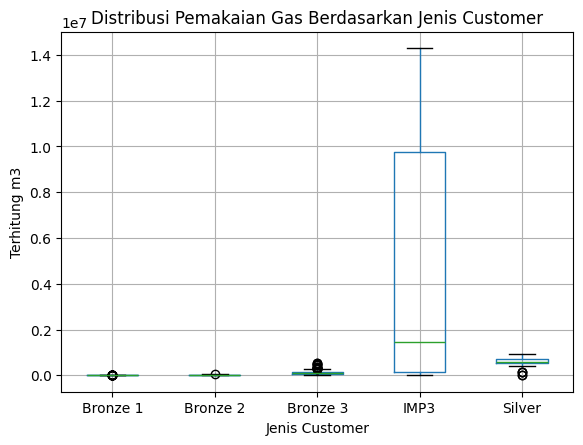

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

data_industri.boxplot(
    column='Terhitung m3',
    by='Jenis Customer'
)

plt.title('Distribusi Pemakaian Gas Berdasarkan Jenis Customer')
plt.suptitle('')
plt.xlabel('Jenis Customer')
plt.ylabel('Terhitung m3')

plt.show()

IMP3 memiliki distribusi pemakaian gas paling tinggi dibandingkan kategori lainnya. Rentangnya sangat besar, hingga sekitar 14,3 juta m3.
Silver berada pada tingkat pemakaian kedua tertinggi, dengan sebagian besar data berada jauh di atas Bronze 1 dan Bronze 2.
Bronze 3 memiliki pemakaian lebih tinggi dibandingkan Bronze 1 dan Bronze 2, tetapi masih jauh di bawah IMP3.
Bronze 1 dan Bronze 2 memiliki pemakaian relatif rendah dan lebih terkonsentrasi.
Terlihat banyak titik pencilan pada Bronze 3, IMP3, dan Silver, sesuai dengan hasil IQR sebelumnya yang menemukan 170 outlier.

In [25]:
# grafik rata-rata pemakaian gas per kategori per tahun.
tren_tahunan = data_industri.groupby(
    ['Tahun', 'Jenis Customer']
)['Terhitung m3'].mean().reset_index()

tren_tahunan

,Tahun,Jenis Customer,Terhitung m3
0,2021,Bronze 1,2.146064e+03
1,2021,Bronze 2,2.484841e+04
2,2021,Bronze 3,1.380866e+05
3,2021,IMP3,2.396835e+06
4,2021,Silver,6.422269e+05
5,2022,Bronze 1,2.189871e+03
6,2022,Bronze 2,2.848000e+04
7,2022,Bronze 3,1.078932e+05
8,2022,IMP3,6.928262e+06
9,2022,Silver,6.063264e+05


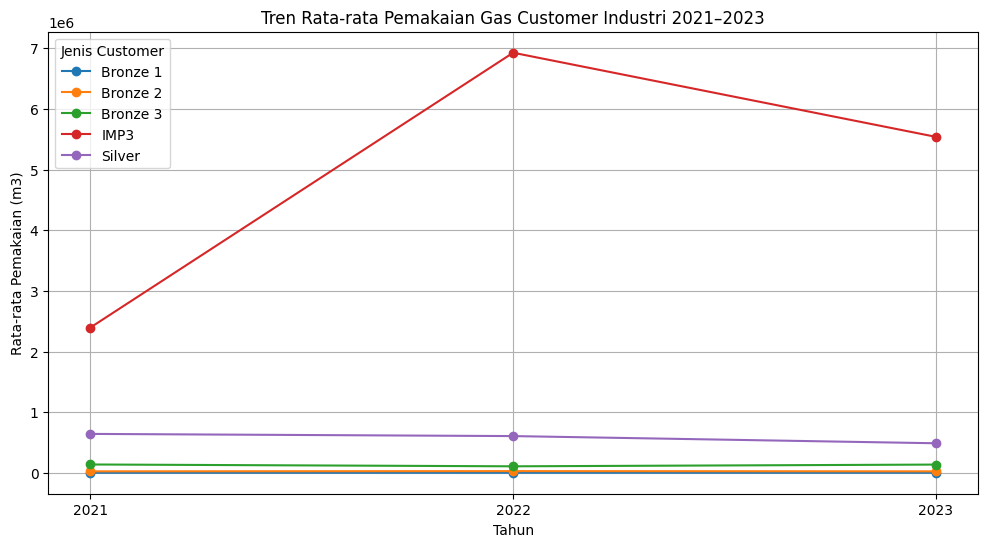

In [26]:
plt.figure(figsize=(12, 6))

for customer in customer_industri:
    data_plot = tren_tahunan[
        tren_tahunan['Jenis Customer'] == customer
    ]

    plt.plot(
        data_plot['Tahun'],
        data_plot['Terhitung m3'],
        marker='o',
        label=customer
    )

plt.title('Tren Rata-rata Pemakaian Gas Customer Industri 2021–2023')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Pemakaian (m3)')
plt.xticks([2021, 2022, 2023])
plt.legend(title='Jenis Customer')
plt.grid(True)

plt.show()

In [27]:
# Mean vs median
perbandingan_mean_median = data_industri.groupby(
    ['Tahun', 'Jenis Customer']
)['Terhitung m3'].agg(
    Rata_Rata='mean',
    Median='median'
).reset_index()

perbandingan_mean_median

,Tahun,Jenis Customer,Rata_Rata,Median
0,2021,Bronze 1,2.146064e+03,1.001000e+03
1,2021,Bronze 2,2.484841e+04,2.330828e+04
2,2021,Bronze 3,1.380866e+05,1.329048e+05
3,2021,IMP3,2.396835e+06,5.616665e+05
4,2021,Silver,6.422269e+05,6.300859e+05
5,2022,Bronze 1,2.189871e+03,1.499914e+03
6,2022,Bronze 2,2.848000e+04,2.268556e+04
7,2022,Bronze 3,1.078932e+05,1.095563e+05
8,2022,IMP3,6.928262e+06,6.098337e+06
9,2022,Silver,6.063264e+05,5.835704e+05


Berdasarkan Exploratory Data Analysis terhadap 1.106 transaksi pelanggan kelompok industri periode 2021-2023, terdapat perbedaan tingkat penggunaan gas yang sangat jelas antar jenis customer. IMP3 memiliki penggunaan gas tertinggi dan menunjukkan fluktuasi paling besar, dengan rata-rata penggunaan meningkat dari sekitar 2,40 juta m3 pada 2021 menjadi 6,93 juta m3 pada 2022, kemudian menurun menjadi 5,54 juta m3 pada 2023. Silver menunjukkan kecenderungan penurunan penggunaan, sedangkan Bronze 1 relatif stabil dan Bronze 2 serta Bronze 3 mengalami fluktuasi. Analisis outlier menemukan 170 transaksi ekstrem, yang didominasi IMP3, Silver, dan Bronze 3. Nilai ekstrem tersebut tidak langsung dihapus karena dapat merepresentasikan karakteristik konsumsi pelanggan industri berskala besar.

In [28]:
# Top 10 perusahaan berdasarkan total penggunaan gas.
top_perusahaan = data_industri.groupby(
    'Account Name'
)['Terhitung m3'].agg(
    Total_Pemakaian='sum',
    Rata_Rata_Pemakaian='mean',
    Jumlah_Transaksi='count'
).sort_values(
    'Total_Pemakaian',
    ascending=False
)

top_perusahaan.head(10)

,Total_Pemakaian,Rata_Rata_Pemakaian,Jumlah_Transaksi
Account Name,,,
"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARAHAN LAMPUNG",2.556962e+08,5.682137e+06,45
PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN LAMPUNG,1.135972e+08,9.466431e+06,12
"PLN (PERSERO), PT. - PLTMG 30 MW SUTAMI LAMPUNG",3.567886e+07,9.910794e+05,36
"LDC INDONESIA, PT.",2.305210e+07,6.586315e+05,35
PT PLN (PERSERO) - PLTMG 30 MW SUTAMI LAMPUNG,1.938512e+07,1.615427e+06,12
"SUMBER INDAHPERKASA, PT.",1.727890e+07,4.936829e+05,35
PT PLN NUSANTARA POWER MPP NEW TARAHAN,1.143390e+07,1.143390e+07,1
"FERMENTECH INDONESIA, PT.",5.563536e+06,1.589582e+05,35
"JAPFA COMFEED INDONESIA TBK., PT.",4.979841e+06,1.422812e+05,35


PLN sangat dominan dalam penggunaan gas industri. 3 entitas teratas saja sudah menunjukkan penggunaan dalam skala puluhan hingga ratusan juta m3. Ini konsisten dengan temuan sebelumnya bahwa IMP3 memiliki konsumsi gas paling tinggi.

In [29]:
# Cek nama duplikat atau hampir sama
data_industri[
    data_industri['Account Name']
    .str.contains('PLN', case=False, na=False)
]['Account Name'].value_counts()

,count
Account Name,
"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARAHAN LAMPUNG",45
"PLN (PERSERO), PT. - PLTMG 30 MW SUTAMI LAMPUNG",36
PT PLN (PERSERO) - PLTMG 30 MW SUTAMI LAMPUNG,12
PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN LAMPUNG,12
PT PLN NUSANTARA POWER SUTAMI,1
PT PLN NUSANTARA POWER MPP NEW TARAHAN,1


In [30]:
# Cek nama hilang pada customer industri
print(
    "Account Name kosong:",
    data_industri['Account Name'].isna().sum()
)

Account Name kosong: 35


In [31]:
# Menggabungkan nama perusahaan yg sama PLN (PERSERO), PT. - PLTMG 30 MW SUTAMI LAMPUNG	PT PLN (PERSERO) - PLTMG 30 MW SUTAMI LAMPUNG
# Membuat kolom baru
data_industri['Account Name Clean'] = data_industri['Account Name']
# Isi nama akun hilang (NaN) pada kolom Account Name menjadi Tidak Diketahui
data_industri['Account Name Clean'] = (
    data_industri['Account Name Clean']
    .fillna('Tidak Diketahui')
)
# Samakan nama kedua perusahaan menjadi 1 perusahaan
data_industri.loc[
    data_industri['Account Name Clean'].isin([
        'PLN (PERSERO), PT. - PLTMG 30 MW SUTAMI LAMPUNG',
        'PT PLN (PERSERO) - PLTMG 30 MW SUTAMI LAMPUNG'
    ]),
    'Account Name Clean'
] = 'PLN - PLTMG 30 MW SUTAMI LAMPUNG'

In [32]:
# Mengecek hasil
data_industri['Account Name Clean'].value_counts().head(15)

,count
Account Name Clean,
"TUNAS BARU LAMPUNG, PT.",49
PLN - PLTMG 30 MW SUTAMI LAMPUNG,48
"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARAHAN LAMPUNG",45
"COCA-COLA BOTTLING INDONESIA, PT.",35
"SUMBER INDAHPERKASA, PT.",35
"FERMENTECH INDONESIA, PT.",35
"JAPFA COMFEED INDONESIA TBK., PT.",35
"AMAN JAYA PERDANA, PT.",35
"ELIM FAJAR MAKMUR, PT.",35


In [33]:
# Mencari perusahaan dengan pemakaian gas terbesar
top_perusahaan_clean = data_industri.groupby(
    'Account Name Clean'
)['Terhitung m3'].agg(
    Total_Pemakaian='sum',
    Rata_Rata_Pemakaian='mean',
    Jumlah_Transaksi='count'
).sort_values(
    'Total_Pemakaian',
    ascending=False
)

top_perusahaan_clean.head(10)

,Total_Pemakaian,Rata_Rata_Pemakaian,Jumlah_Transaksi
Account Name Clean,,,
"PLN (PERSERO), PT. - PLTMG MPP 100 MW NEW TARAHAN LAMPUNG",2.556962e+08,5.682137e+06,45
PT PLN (PERSERO) - PLTG MPP 100 MW NEW TARAHAN LAMPUNG,1.135972e+08,9.466431e+06,12
PLN - PLTMG 30 MW SUTAMI LAMPUNG,5.506398e+07,1.147166e+06,48
"LDC INDONESIA, PT.",2.305210e+07,6.586315e+05,35
"SUMBER INDAHPERKASA, PT.",1.727890e+07,4.936829e+05,35
PT PLN NUSANTARA POWER MPP NEW TARAHAN,1.143390e+07,1.143390e+07,1
Tidak Diketahui,1.123142e+07,3.208976e+05,35
"FERMENTECH INDONESIA, PT.",5.563536e+06,1.589582e+05,35
"JAPFA COMFEED INDONESIA TBK., PT.",4.979841e+06,1.422812e+05,35


Berdasarkan hasil Exploratory Data Analysis, penggunaan gas pelanggan industri menunjukkan konsentrasi yang cukup tinggi pada beberapa perusahaan. Perusahaan dengan total pemakaian terbesar adalah PLN (PERSERO), PT. - PLTMG MPP 100 MW New Tarahan Lampung, dengan total pemakaian sekitar 255,70 juta m3 selama periode 2021-2023. Posisi berikutnya adalah PT PLN (PERSERO) - PLTG MPP 100 MW New Tarahan Lampung dengan sekitar 113,60 juta m3. Hal ini menunjukkan bahwa pelanggan dengan karakteristik penggunaan gas untuk pembangkitan listrik memiliki volume konsumsi yang jauh lebih besar dibandingkan sebagian besar pelanggan industri lainnya.

In [34]:
# Total pemakaian berdasarkan jenis customer
pemakaian_customer = data_industri.groupby(
    'Jenis Customer'
)['Terhitung m3'].agg(
    Total_Pemakaian='sum',
    Rata_Rata_Pemakaian='mean',
    Median_Pemakaian='median',
    Jumlah_Transaksi='count'
).sort_values(
    'Total_Pemakaian',
    ascending=False
)

pemakaian_customer

,Total_Pemakaian,Rata_Rata_Pemakaian,Median_Pemakaian,Jumlah_Transaksi
Jenis Customer,,,,
IMP3,4.454675e+08,4.086858e+06,1.475513e+06,109
Silver,3.701195e+07,5.874913e+05,5.835704e+05,63
Bronze 3,2.653276e+07,1.275613e+05,1.219600e+05,208
Bronze 2,4.911309e+06,2.612398e+04,2.356633e+04,188
Bronze 1,1.181129e+06,2.195407e+03,1.533151e+03,538


In [35]:
# Kontribusi Persentase
pemakaian_customer['Kontribusi_%'] = (
    pemakaian_customer['Total_Pemakaian']
    / pemakaian_customer['Total_Pemakaian'].sum()
    * 100
)

pemakaian_customer

,Total_Pemakaian,Rata_Rata_Pemakaian,Median_Pemakaian,Jumlah_Transaksi,Kontribusi_%
Jenis Customer,,,,,
IMP3,4.454675e+08,4.086858e+06,1.475513e+06,109,86.480972
Silver,3.701195e+07,5.874913e+05,5.835704e+05,63,7.185326
Bronze 3,2.653276e+07,1.275613e+05,1.219600e+05,208,5.150945
Bronze 2,4.911309e+06,2.612398e+04,2.356633e+04,188,0.953458
Bronze 1,1.181129e+06,2.195407e+03,1.533151e+03,538,0.229299


In [38]:
# Simpan data yang sudah dibersihkan dan difilter
data_industri.to_csv(
    'data_industri_tableau.csv',
    index=False
)

#Visualisasi menggunakan tableau
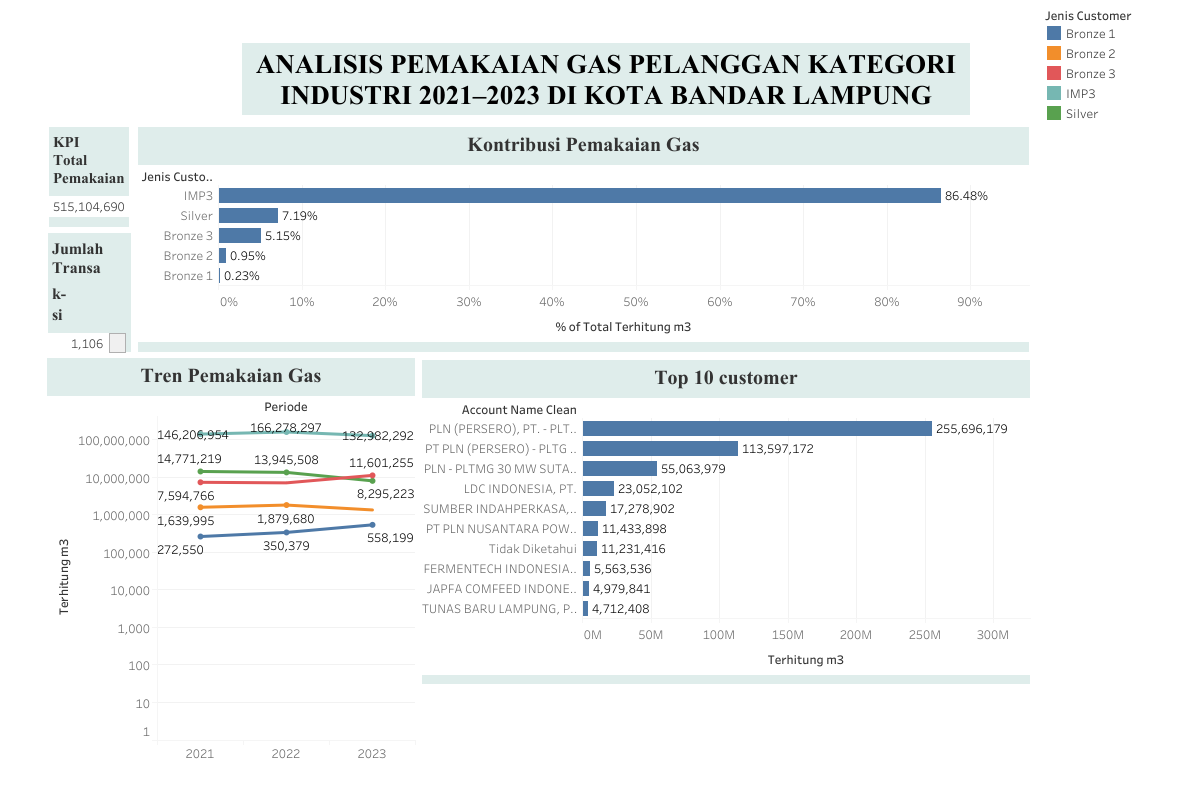

Selengkapnya di:
https://public.tableau.com/views/VisualisasiPemakaianGasPelangganKategoriIndustri2021-2023KotaBandarLampung/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link